# DTLZ3 Results

In [ ]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 5
NPOP = 640
NGEN = 500
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz3_segura = partial(benchmarks.dtlz3, obj=NOBJ)
toolbox = build_toolbox(func_dtlz3_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...


(0.0, 0.0, 0.500007604436858, 0.0)
(0.0, 0.0, 0.0, 0.5000006139879272)
(0.5000008305971466, 0.0, 0.0, 0.0)
(0.5000008305971466, 0.0, 0.0, 0.0)
(1.7049094257279163e-17, 0.5000004426909062, 0.0, 0.0)
(0.09780918348297314, 0.19693005314393994, 0.0005131501062533219, 0.20474792802301028)
(0.05813636980281803, 0.12320715291046978, 0.1721123175517534, 0.14655160536662556)
(0.0027041288899065314, 1.826389382663346e-05, 0.4629496083896574, 0.2634132658517736)
(0.08625768035270485, 0.3428438105364361, 0.03698784625528216, 0.033937354338289843)
(0.11782044681845216, 0.2395037366559302, 0.12769991438327327, 0.014978227609096808)
(0.20683349625424316, 0.05372500151884075, 0.13595216231803708, 0.10351139063923177)
(0.0034649427752650526, 0.00010648671337197683, 0.32101625301829473, 0.1754206210684955)
(0.4183556227517071, 0.021293888405950843, 0.0, 0.07259618808261847)
(0.16264970143061644, 0.01900932512153179, 0.014457601639687668, 0.3038837040904103)
(0.07577777544138842, 0.1607638610441641, 0.26

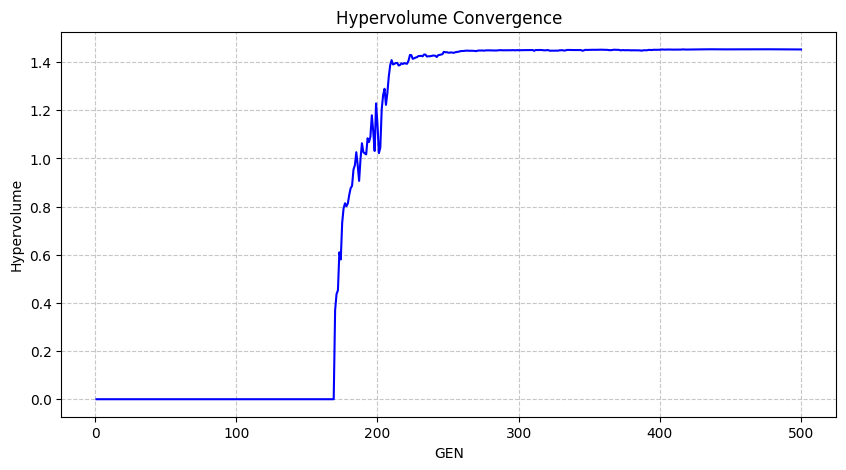

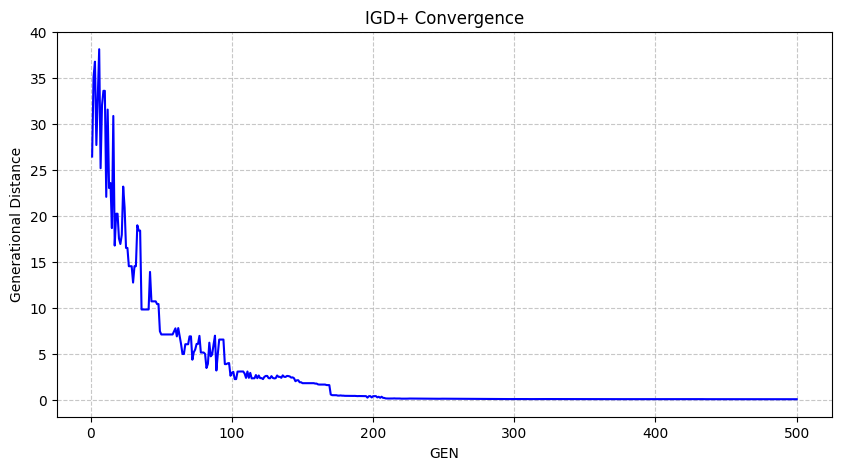

In [ ]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()